#### Figures for academic poster

In [52]:
# imports for functionality 
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

from dissertation_simulations.params import electrode_sim_params_full
from dissertation_simulations.generate_electrodes import generate_1D_electrodes_ap
from dissertation_simulations.exponents import gen_exponents
from dissertation_simulations.psd import avg_psd
from dissertation_simulations.params import spectral_model_params

from specparam import SpectralModel
from dissertation_simulations.params import freq_range
from dissertation_simulations.exponents import generate_spatial_exponent_matrix, generate_2D_exponent_matrix
from dissertation_simulations.plotting import plot_summary_boxplots
from dissertation_simulations.exponents import generate_spatial_exponent_matrix, generate_2D_exponent_matrix
from dissertation_simulations.loading_summaries import load_distribution_summary
from dissertation_simulations.plotting import add_significance_bracket
from dissertation_simulations.plotting import cohens_d
from dissertation_simulations.plotting import tukey_with_cohens_d
from dissertation_simulations.plotting import add_panel_tukey_brackets

import pandas as pd
import statsmodels.api as sm

from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from neurodsp.sim import sim_oscillation, sim_combined, sim_powerlaw
from dissertation_simulations.params import welch_params
from neurodsp.spectral import compute_spectrum_welch
from specparam.plts import plot_spectra

In [54]:
sns.set_theme(
    style="white",
    context="poster",
)

##### PSD example

[-1.0879416962427473]


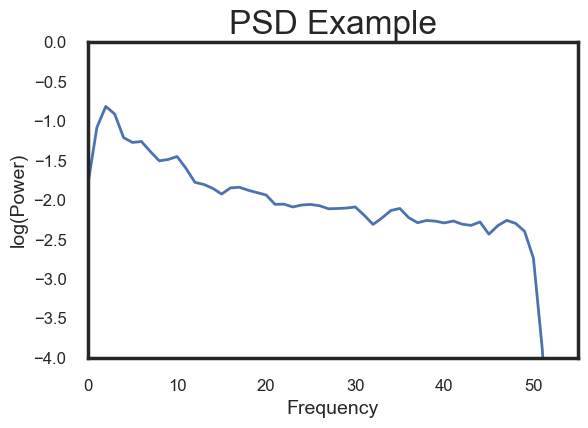

In [31]:
# Load in copy of parameters
params = electrode_sim_params_full.copy()

# Generate random exponents
exponents = gen_exponents(1, (-2, -1))
print(exponents)

# Generate 1D electrode array
signals, params_list, times = generate_1D_electrodes_ap(1, exponents, params)

# Compute and plot average PSD
psds, avg_powers, freqs, fig, ax = avg_psd(signals, params)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures Final\PSDExamplePoster.png", dpi=300, bbox_inches="tight")

##### Spectral Model example

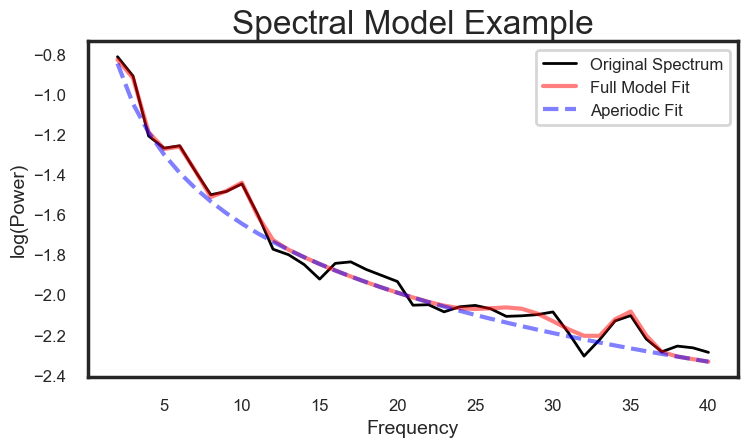

In [34]:
fm = SpectralModel(**spectral_model_params)
freq_range = freq_range

fm.fit(
    freqs,
    avg_powers,
    freq_range,
)

fig, ax = plt.subplots(figsize=(8, 5))

fm.plot(ax=ax)
ax.set_title(
    "Spectral Model Example")

ax.grid(False, which="both")

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures Final\SpectralModelExamplePoster.png", dpi=300, bbox_inches="tight",)

plt.show()

##### Averaging method figure

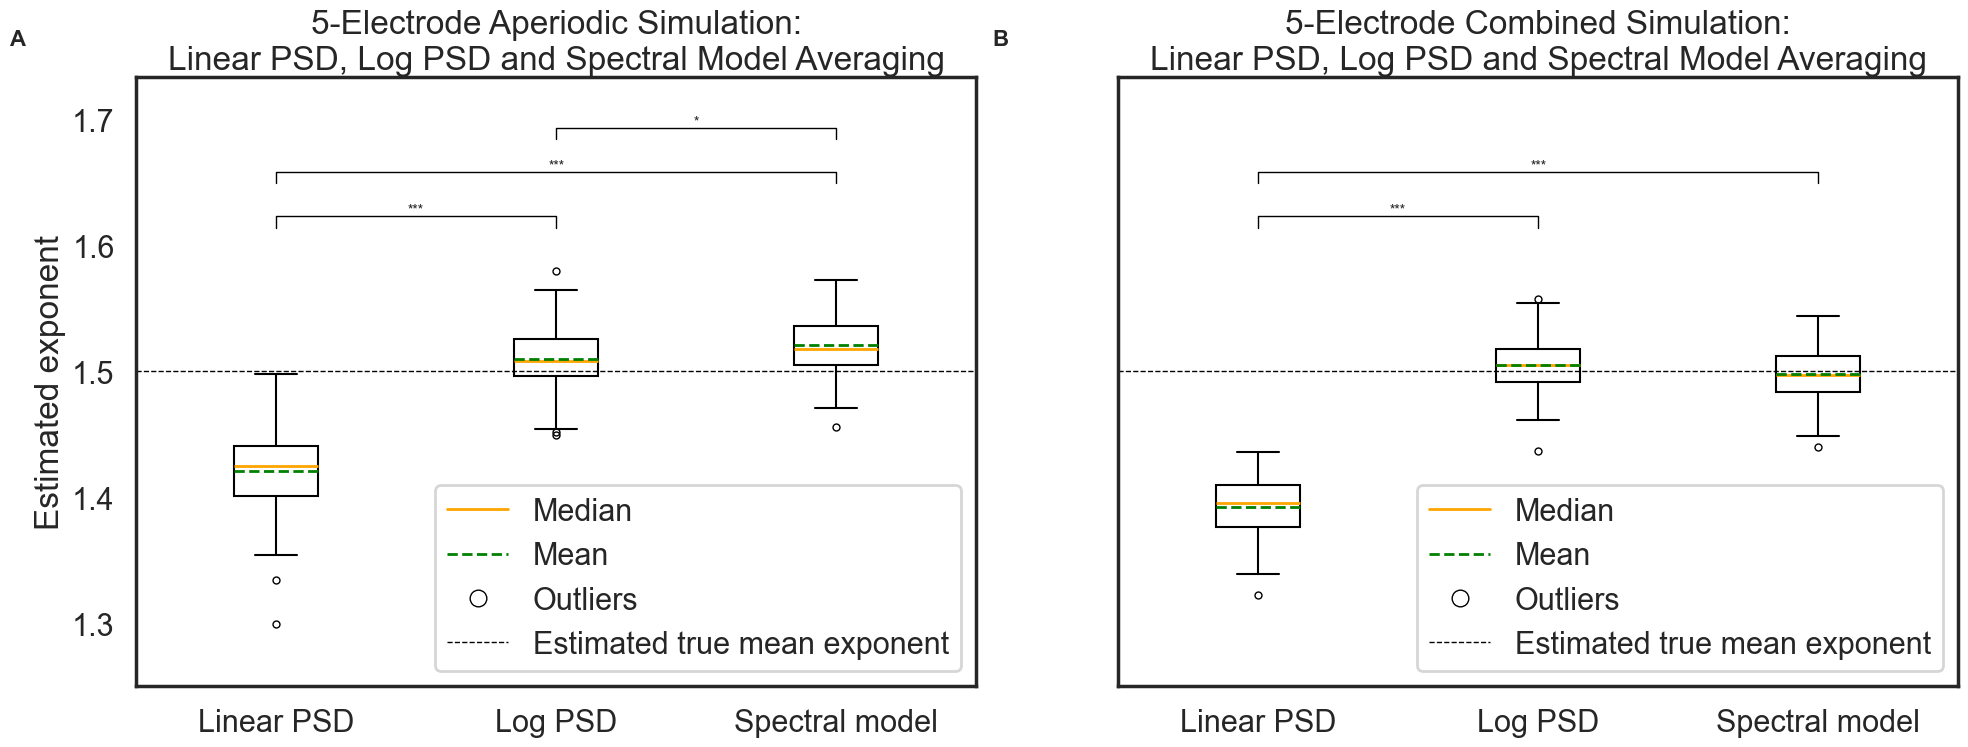

In [16]:
common_ylim = (1.25, 1.6)

labels = [
    "Linear PSD",
    "Log PSD",
    "Spectral model",
]

distribution_index = 0

panel_configs = [
    {
        "simulation_type": "Aperiodic simulation",
        "title": (
            "5-Electrode Aperiodic Simulation:\n"
            "Linear PSD, Log PSD and Spectral Model Averaging"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp5aresults1_psd_linear_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp5aresults2_psd_log_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp5aresults3_specmod_exp_matrix_cols_-1-2.json",
        ],
        "ylim": common_ylim,
        "true_mean_exp": np.mean(
            -generate_2D_exponent_matrix(
                grid_shape=(1, 5),
                exp_range=(-2, -1),
                gradient_axis="cols",
            )
        ),
    },
    {
        "simulation_type": "Combined simulation",
        "title": (
            "5-Electrode Combined Simulation:\n"
            "Linear PSD, Log PSD and Spectral Model Averaging"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1aresults1_psd_linear_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1aresults2_psd_log_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1aresults3_specmod_exp_matrix_cols_-1-2.json",
        ],
        "ylim": common_ylim,
        "true_mean_exp": np.mean(
            -generate_2D_exponent_matrix(
                grid_shape=(1, 5),
                exp_range=(-2, -1),
                gradient_axis="cols",
            )
        ),
    }]

data_rows = []

for panel in panel_configs:
    for path, method in zip(panel["summary_paths"], labels):
        _, distributions = load_distribution_summary(path)

        estimates = np.asarray(distributions[distribution_index])

        for estimate in estimates:
            data_rows.append({
                "estimate": estimate,
                "method": method,
                "simulation_type": panel["simulation_type"],
            })

df = pd.DataFrame(data_rows)

two_way_model = ols(
    "estimate ~ C(method) + C(simulation_type)",
    data=df,
).fit()

two_way_anova = sm.stats.anova_lm(two_way_model, typ=2)

method_tukey, method_posthoc = tukey_with_cohens_d(df, "method")
simulation_tukey, simulation_posthoc = tukey_with_cohens_d(
    df,
    "simulation_type",
)

fig, axes = plt.subplots(1, 2,
    figsize=(20, 8),
    sharey=True,
)

axes = axes.ravel()

for i, panel in enumerate(panel_configs):
    plot_summary_boxplots(
        summary_paths=panel["summary_paths"],
        labels=labels,
        title=panel["title"],
        true_mean_exp=panel["true_mean_exp"],
        ylim=panel["ylim"],
        ylabel="Estimated exponent" if i == 0 else "",
        ax=axes[i],
        show=False,
    )

    panel_data = df.loc[
        df["simulation_type"] == panel["simulation_type"]
    ]

    panel_posthoc = add_panel_tukey_brackets(
        ax=axes[i],
        panel_data=panel_data,
        base_ylim=panel["ylim"],
        labels=labels
    )


# Panel labels.
for ax, letter in zip(axes[:3], ["A", "B"]):
    ax.text(
        -0.15,
        1.08,
        letter,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )

fig.tight_layout()

fig.savefig(
    r"C:\Users\chloe\DissertationSimulations\Figures Final\AveragingMethodPoster.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

##### Location figure

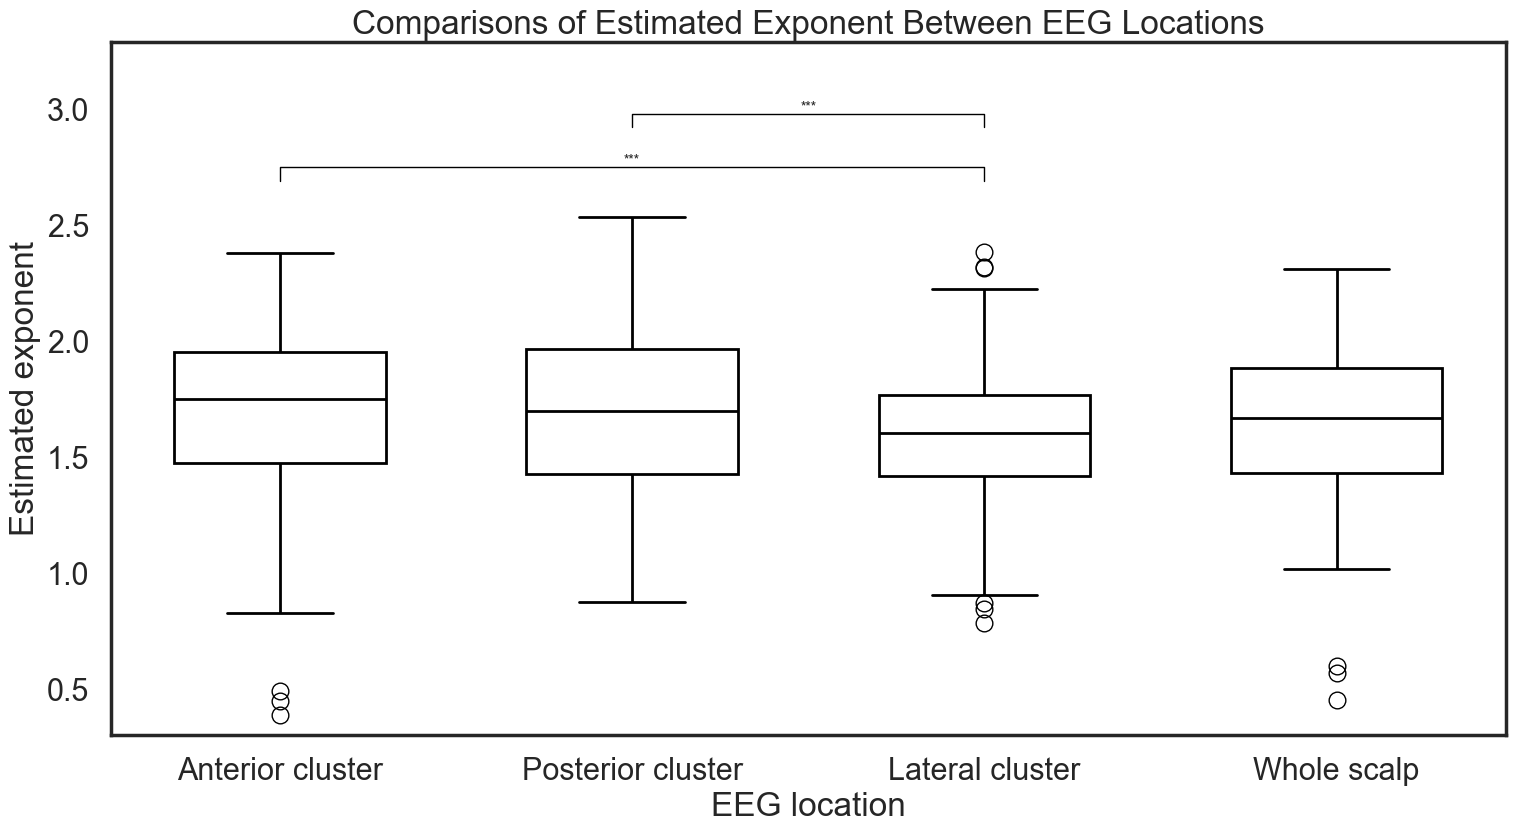

In [27]:
common_ylim = (0.3, 2.6)

location_panels = [
    {
        "location": "Anterior cluster",
        "title": (
            "5-Electrode Anterior Cluster EEG Data:\n"
            "Comparison of Linear PSD, Log PSD and Spectral Model Averaging"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1cresults1_eeg_psd_linear_5elec_anterior.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1cresults2_eeg_psd_log_5elec_anterior.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1cresults3_eeg_specmod_5elec_anterior.json",
        ],
    },
    {
        "location": "Posterior cluster",
        "title": (
            "5-Electrode Posterior Cluster EEG Data:\n"
            "Comparison of Linear PSD, Log PSD and Spectral Model Averaging"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1dresults1_eeg_psd_linear_5elec_posterior.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1dresults2_eeg_psd_log_5elec_posterior.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1dresults3_eeg_specmod_5elec_posterior.json",
        ],
    },
    {
        "location": "Lateral cluster",
        "title": (
            "5-Electrode Lateral Cluster EEG Data:\n"
            "Comparison of Linear PSD, Log PSD and Spectral Model Averaging"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1eresults1_eeg_psd_linear_5elec_lateral.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1eresults2_eeg_psd_log_5elec_lateral.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1eresults3_eeg_specmod_5elec_lateral.json",
        ],
    },
    {
        "location": "Whole scalp",
        "title": (
            "Whole-Scalp EEG Data:\n"
            "Comparison of Linear PSD, Log PSD and Spectral Model Averaging"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1bresults1_eeg_psd_linear_111elec_full.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1bresults2_eeg_psd_log_111elec_full.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1bresults3_eeg_specmod_111elec_full.json",
        ],
    },]

data_rows = []

for panel in location_panels:
    for path, method in zip(panel["summary_paths"], labels):
        _, distributions = load_distribution_summary(path)

        estimates = np.asarray(distributions[distribution_index])

        for estimate in estimates:
            data_rows.append({
                "estimate": estimate,
                "method": method,
                "location": panel["location"],
            })

df_2way = pd.DataFrame(data_rows)

# Two-way ANOVA INCLUDING the interaction
two_way_model = ols(
    "estimate ~ C(method) * C(location)",
    data=df_2way,
).fit()

two_way_anova = sm.stats.anova_lm(
    two_way_model,
    typ=2,
)

location_tukey, location_posthoc = tukey_with_cohens_d(
        df_2way,
        "location",
    )

location_order = [
    "Anterior cluster",
    "Posterior cluster",
    "Lateral cluster",
    "Whole scalp",
]



fig, ax = plt.subplots(figsize=(18, 9))

sns.boxplot(
    data=df_2way,
    x="location",
    y="estimate",
    order=location_order,
    ax=ax,
    color="white",
    linecolor="black",
    width = 0.6,
    linewidth=2,
)

ax.set_title("Comparisons of Estimated Exponent Between EEG Locations")
ax.set_xlabel("EEG location")
ax.set_ylabel("Estimated exponent")
ax.grid(False, which="both")

# Base plotting range, before significance brackets.
y_min, y_max = common_ylim
ax.set_ylim(y_min, y_max)

significant_locations = location_posthoc.loc[
    location_posthoc["significant"]
].reset_index(drop=True)

location_positions = {
    location: position
    for position, location in enumerate(location_order)
}

y_range = y_max - y_min
bracket_height = 0.025 * y_range
bracket_spacing = 0.10 * y_range
start_y = y_max + 0.04 * y_range

for i, row in significant_locations.iterrows():
    p_value = row["p_adjusted"]

    if p_value < 0.001:
        stars = "***"
    elif p_value < 0.01:
        stars = "**"
    else:
        stars = "*"

    add_significance_bracket(
        ax=ax,
        x1=location_positions[row["group1"]],
        x2=location_positions[row["group2"]],
        y=start_y + i * bracket_spacing,
        height=bracket_height,
        text=stars,
    )

# Make room for brackets.
ax.set_ylim(
    y_min,
    y_max + (len(significant_locations) + 1) * bracket_spacing,
)

fig.savefig(
    r"C:\Users\chloe\DissertationSimulations\Figures Final\EEGLocationEffectPoster.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

##### PSD and Spectral Model
- contains 10Hz oscillation
- figures plotted on same axis 

In [49]:
params = electrode_sim_params_full # Params dict that contains simulation setting for full electrode signal


n_seconds = params["n_seconds"]
fs = params["s_rate"]
high_pass_filter = params["high_pass_filter"]
low_pass_filter = params["low_pass_filter"]
freq = params ["oscillation"]

components = {
    'sim_powerlaw': {'exponent':-1.5, 'f_range': [high_pass_filter, low_pass_filter]},
    'sim_oscillation': {'freq': freq}
}

electrode_signal_full = sim_combined(n_seconds, fs, components=components)  

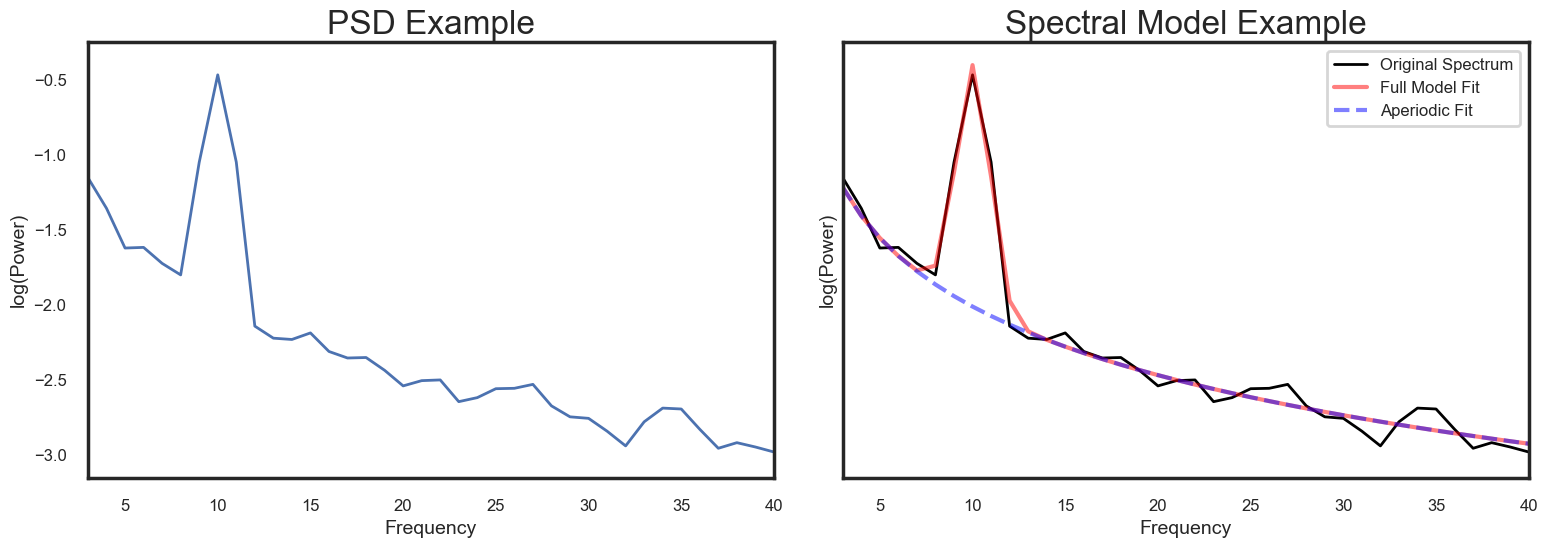

In [71]:
fm = SpectralModel(**spectral_model_params)

fm.fit(
    freqs_full,
    powers_full,
    freq_range,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    sharex=True,
    sharey=True,
    layout="constrained",
)


# Panel A: PSD
welch_dict = welch_params(params)

freqs_full, powers_full = compute_spectrum_welch(
    electrode_signal_full,
    fs,
    **welch_dict,
)

plot_spectra(
    freqs_full,
    powers_full,
    log_powers=True,
    ax=axes[0],
)

axes[0].set_title("PSD Example")
axes[0].grid(False, which="both")


# Panel B: Spectral model
fm.plot(ax=axes[1])

axes[1].set_title("Spectral Model Example")
axes[1].grid(False, which="both")


# Shared axis ranges
for ax in axes:
    ax.set_xlim(3, 40)
    ax.set_ylim(-3.15, -0.25)

# Save before displaying.
fig.savefig(
    r"C:\Users\chloe\DissertationSimulations\Figures Final\PSD_and_SpectralModel.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()